In [134]:
import yfinance as yf

In [135]:
import pandas as pd


In [136]:
import numpy as np

In [137]:
import sys, os

In [138]:
sys.path.append(os.path.abspath(".."))

In [139]:
from equitytools_local.data import download_price_data

In [140]:
import equitytools_local.data as datatools

In [165]:
from importlib import reload
reload(datatools)

<module 'equitytools_local.data' from 'C:\\Users\\jonsw\\AppData\\Local\\Packages\\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\\LocalCache\\local-packages\\Python311\\Scripts\\equitytools_local\\data.py'>

In [166]:
ticker_symbol = "MSFT"

In [143]:
start_date = '2025-01-01'

In [144]:
end_date = '2026-02-02'

In [145]:
stock_data = datatools.download(ticker_symbol, start=start_date, end=end_date)

[*********************100%***********************]  1 of 1 completed


## Calculating Daily Returns

In [146]:
stock_data['returns'] = stock_data['Close'].pct_change()

In [147]:
print(stock_data)

Price            Close        High         Low        Open     Volume  \
Ticker            MSFT        MSFT        MSFT        MSFT       MSFT   
Date                                                                    
2025-01-02  415.514832  422.950005  411.812165  422.413951   16896500   
2025-01-03  420.249878  420.924891  416.467780  417.996481   16662900   
2025-01-06  424.716949  431.139572  422.364309  424.865845   20573600   
2025-01-07  419.277069  427.496435  417.718559  425.858524   18139100   
2025-01-08  421.451019  423.843375  418.453145  420.359068   15054600   
...                ...         ...         ...         ...        ...   
2026-01-26  470.279999  474.250000  462.000000  465.309998   29291200   
2026-01-27  480.579987  482.869995  473.160004  473.700012   29213900   
2026-01-28  481.630005  483.739990  478.000000  483.209991   36875400   
2026-01-29  433.500000  442.500000  421.019989  439.989990  128855300   
2026-01-30  430.290009  439.600006  426.450012  439

In [148]:
window_size = 5

In [149]:
stock_data['volatility'] = stock_data['returns'].rolling(window=window_size).std() * np.sqrt(252) # Annualized volatility

In [150]:
print(stock_data)

Price            Close        High         Low        Open     Volume  \
Ticker            MSFT        MSFT        MSFT        MSFT       MSFT   
Date                                                                    
2025-01-02  415.514832  422.950005  411.812165  422.413951   16896500   
2025-01-03  420.249878  420.924891  416.467780  417.996481   16662900   
2025-01-06  424.716949  431.139572  422.364309  424.865845   20573600   
2025-01-07  419.277069  427.496435  417.718559  425.858524   18139100   
2025-01-08  421.451019  423.843375  418.453145  420.359068   15054600   
...                ...         ...         ...         ...        ...   
2026-01-26  470.279999  474.250000  462.000000  465.309998   29291200   
2026-01-27  480.579987  482.869995  473.160004  473.700012   29213900   
2026-01-28  481.630005  483.739990  478.000000  483.209991   36875400   
2026-01-29  433.500000  442.500000  421.019989  439.989990  128855300   
2026-01-30  430.290009  439.600006  426.450012  439

In [151]:
# Loop starting from the second item (index 1)
for idx, value in stock_data['returns'].iloc[1:].items():
    # print(f"Index: {idx}, Return: {value}")
    assert abs(value) >= 0

In [152]:
assert np.isnan(stock_data['returns'].iloc[0]) , "expected first return to be NaN"

# Plot Stock Volatility 

In [160]:
import equitytools_local.plotting as plottingtools

In [161]:
reload(plottingtools)

<module 'equitytools_local.plotting' from 'C:\\Users\\jonsw\\AppData\\Local\\Packages\\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\\LocalCache\\local-packages\\Python311\\Scripts\\equitytools_local\\plotting.py'>

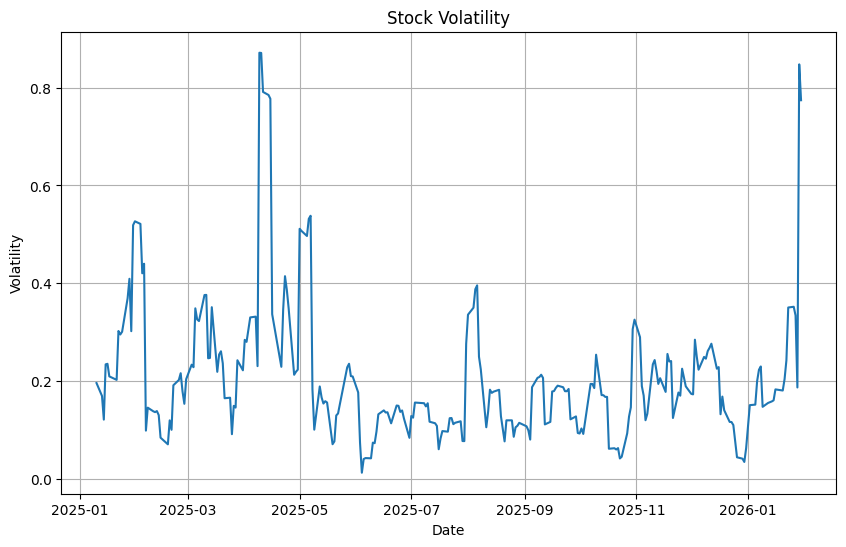

In [162]:
plottingtools.plot_volatility(stock_data)

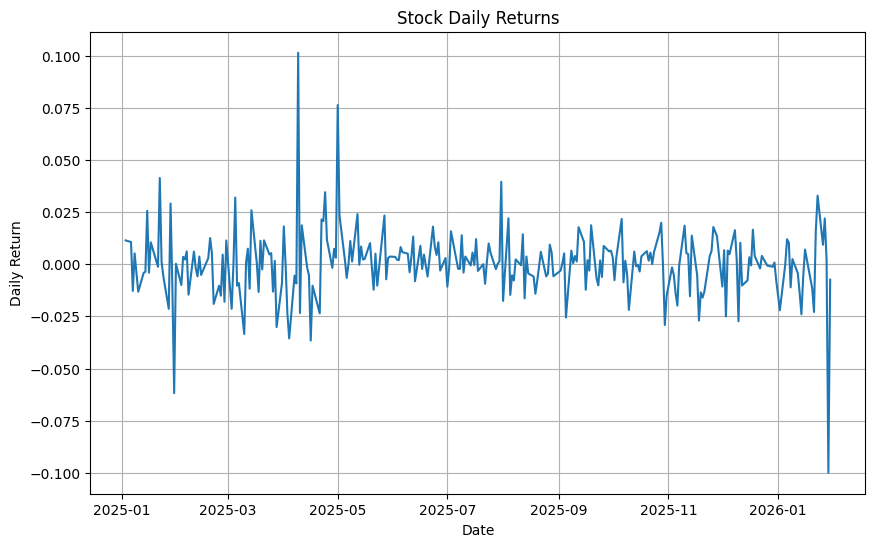

In [163]:
plottingtools.plot_stock_daily_returns(stock_data)

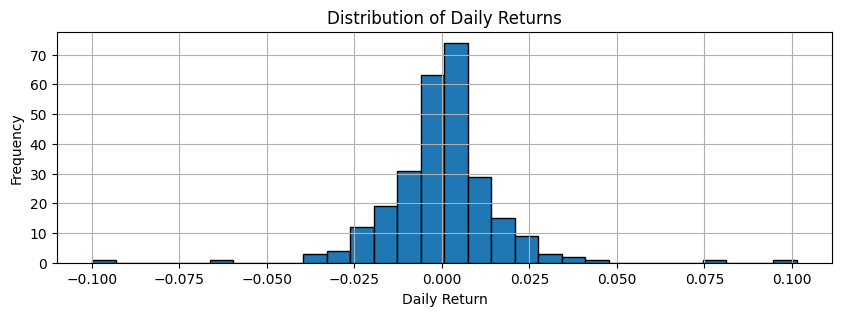

In [164]:
plottingtools.plot_histogram_of_stock_returns(stock_data)